# ภม.338 Geographic Data Science — Lab 2
## Spatial Analysis กับ Google Earth Engine
### พื้นที่ศึกษา: จังหวัดหนองคาย ประเทศไทย

| รายละเอียด | ข้อมูล |
|---|---|
| **ดาวเทียม** | Sentinel-2 Surface Reflectance (SR) |
| **ช่วงเวลา** | ฤดูแล้ง (ม.ค.-เม.ย. 2023) vs. ฤดูฝน (มิ.ย.–ต.ค. 2023) |
| **เครื่องมือ** | Google Earth Engine Python API + geemap |

---
## เหตุผลการเลือกพื้นที่: จังหวัดหนองคาย

จังหวัดหนองคายตั้งอยู่ริมแม่น้ำโขง ชายแดนไทย-ลาว มีลักษณะทางภูมิศาสตร์ที่น่าสนใจหลายประการ:
- **แม่น้ำโขง**: แหล่งน้ำขนาดใหญ่ที่ระดับน้ำแปรผันตามฤดูกาลอย่างชัดเจน
- **พื้นที่เกษตรกรรม**: ทุ่งนาและพืชไร่ริมแม่น้ำที่ได้รับผลกระทบจากความชื้นในดิน
- **ความแตกต่างระหว่างฤดูกาล**: NDVI และดัชนีน้ำเปลี่ยนแปลงอย่างชัดเจน เหมาะสำหรับการเปรียบเทียบ

วัตถุประสงค์: พืชพรรณและแหล่งน้ำในจังหวัดหนองคายเปลี่ยนแปลงอย่างไรระหว่างฤดูแล้งและฤดูฝน?

In [164]:

!pip install geemap -q
!pip install earthengine-api -q
!pip install pycrs -q

In [165]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display
import geopandas as gpd
import json
ee.Authenticate()
ee.Initialize(project='ee-khehathancencira')


In [166]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## ภารกิจที่ 1: กำหนดพื้นที่ศึกษา จังหวัดหนองคาย

In [167]:
SHP_PATH = '/content/NK1.shp'

gdf = gpd.read_file(SHP_PATH)
print(f'CRS ของ SHP: {gdf.crs}')
print(f'จำนวน features: {len(gdf)}')
print(f'Columns: {list(gdf.columns)}')

# แปลงเป็น WGS84
if gdf.crs and gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs(epsg=4326)
    print('🔄 Reprojected to WGS84 (EPSG:4326)')

# แปลง GeoDataFrame
geojson_dict = json.loads(gdf.to_json())
aoi = ee.FeatureCollection(geojson_dict['features'])
aoi_geometry = aoi.geometry()


bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2
print(f'\nCenter: lat={center_lat:.4f}, lon={center_lon:.4f}')

CRS ของ SHP: GEOGCS["GCS_WGS_84_CRS84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
จำนวน features: 9
Columns: ['AMP_CODE', 'PRV_CODE', 'AMP_NAME_T', 'AMP_NAME_E', 'Shape_Leng', 'TH_Provinc', 'TH_Provi_1', 'Shape_Le_1', 'Shape_Area', 'geometry']
🔄 Reprojected to WGS84 (EPSG:4326)

Center: lat=17.9482, lon=102.7341


---
## ภารกิจที่ 2: เลือกดาวเทียมและกรองข้อมูล Sentinel-2

### เหตุผลการเลือก Sentinel-2

**เลือก Sentinel-2** เพราะต้องการความละเอียด 10 เมตร เพื่อแยกแยะพื้นที่เกษตรและแนวแม่น้ำโขงได้ชัดเจน และมีภาพในช่วงเวลาที่ศึกษา

### ช่วงเวลาที่เลือก
- **ฤดูแล้ง**: มกราคม–เมษายน 2023 (CLOUD_COVERAGE < 10%)
- **ฤดูฝน**: มิถุนายน–ตุลาคม 2023 (CLOUD_COVERAGE < 20% เพราะมีเมฆมาก)
การเลือกช่วงเวลนี้อ้างอิงจาก กรมอุตุนิยมวิทยา https://www.tmd.go.th/info/%E0%B8%A0%E0%B8%A2%E0%B9%81%E0%B8%A5%E0%B8%87

In [168]:


def mask_s2_clouds(image):
    """Mask ก้อนเมฆโดยใช้ SCL band (Scene Classification Layer)"""
    scl = image.select('SCL')
    clear_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(clear_mask).divide(10000)  # Scale factor สำหรับ SR


s2_dry = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2023-01-01', '2023-04-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))  # เกณฑ์เมฆ < 10%
    .map(mask_s2_clouds)
)


s2_wet = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate('2023-06-01', '2023-10-30')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))  # ผ่อนปรนเป็น 20% ในฤดูฝน
    .map(mask_s2_clouds)
)

# สร้าง Median Composite
composite_dry = s2_dry.median().clip(aoi)
composite_wet = s2_wet.median().clip(aoi)

# แสดงจำนวนภาพ
n_dry = s2_dry.size().getInfo()
n_wet = s2_wet.size().getInfo()
print(f'📷 จำนวนภาพฤดูแล้ง  (cloud < 10%): {n_dry} ภาพ')
print(f'📷 จำนวนภาพฤดูฝน   (cloud < 20%): {n_wet} ภาพ')
print()

📷 จำนวนภาพฤดูแล้ง  (cloud < 10%): 110 ภาพ
📷 จำนวนภาพฤดูฝน   (cloud < 20%): 20 ภาพ



In [169]:
vis_rgb = {'min': 0, 'max': 0.3, 'bands': ['B4', 'B3', 'B2'], 'gamma': 1.4}

Map2 = geemap.Map(center=[17.878, 102.746], zoom=9)
Map2.addLayer(composite_dry, vis_rgb, 'Sentinel-2 True Color — ฤดูแล้ง (ม.ค.-เม.ย. 2023)')
Map2.addLayer(composite_wet, vis_rgb, 'Sentinel-2 True Color — ฤดูฝน (มิ.ย.-ตุ.ค. 2023)', shown=False)
Map2.addLayer(aoi, {'color': 'red', 'fillColor': '00000000', 'width': 2}, 'ขอบเขตหนองคาย')
Map2.add_layer_manager()
Map2

Map(center=[17.878, 102.746], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

---
## ภารกิจที่ 3: การวิเคราะห์เชิงพื้นที่
### 3.1 คำนวณ Spectral Indices (NDVI, NDWI, MNDWI)

In [170]:
#  คำนวณ Spectral Indices
#   - NDVI  : Normalized Difference Vegetation Index
#   - NDWI  : Normalized Difference Water Index (Gao 1996)
#   - MNDWI : Modified NDWI (Xu 2006) — ดีกว่า NDWI สำหรับน้ำในเมือง
#   - SAVI  : Soil-Adjusted Vegetation Index — ลดผลกระทบดิน


def compute_indices(image):
    """คำนวณ Spectral Indices จาก Sentinel-2"""
    # Band references: B2=Blue, B3=Green, B4=Red, B8=NIR, B11=SWIR1, B12=SWIR2

    # NDVI = (NIR - Red) / (NIR + Red)
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

    # NDWI = (Green - NIR) / (Green + NIR)  — ตรวจจับน้ำผิวดิน
    ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    # MNDWI = (Green - SWIR1) / (Green + SWIR1) — ดีกว่า NDWI ในพื้นที่เกษตร
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')

    # SAVI = ((NIR - Red) / (NIR + Red + L)) * (1 + L)  โดย L = 0.5
    L = 0.5
    nir  = image.select('B8')
    red  = image.select('B4')
    savi = nir.subtract(red).divide(nir.add(red).add(L)).multiply(1 + L).rename('SAVI')

    return image.addBands([ndvi, ndwi, mndwi, savi])

dry_indices = compute_indices(composite_dry)
wet_indices  = compute_indices(composite_wet)


In [171]:
# Visualization Parameters
vis_ndvi  = {'min': -0.2, 'max': 0.8, 'palette': ['#d73027','#f46d43','#fdae61',
                                                    '#fee08b','#d9ef8b','#a6d96a',
                                                    '#66bd63','#1a9850']}
vis_ndwi  = {'min': -0.5, 'max': 0.5, 'palette': ['#8B4513','#D2B48C','#F5F5DC',
                                                    '#87CEEB','#1E90FF','#00008B']}
vis_mndwi = {'min': -0.5, 'max': 0.5, 'palette': ['#8B4513','#DEB887','#FFFACD',
                                                    '#ADD8E6','#4169E1','#000080']}
vis_savi  = {'min': 0.0, 'max': 1.0, 'palette': ['#000080','#0000D9','#4000FF',
                                                    '#8000FF','#0080FF','#00FF8B',]}
# แสดงผล NDVI บนแผนที่
Map3 = geemap.Map(center=[17.878, 102.746], zoom=9)
Map3.addLayer(dry_indices.select('NDVI'),  vis_ndvi,  'NDVI — ฤดูแล้ง')
Map3.addLayer(wet_indices.select('NDVI'),  vis_ndvi,  'NDVI — ฤดูฝน', shown=False)
Map3.addLayer(dry_indices.select('NDWI'), vis_ndwi, 'NDWI — Dry Season', shown=False)
Map3.addLayer(wet_indices.select('NDWI'), vis_ndwi, 'NDWI — Wet Season', shown=False)
Map3.addLayer(dry_indices.select('MNDWI'), vis_mndwi, 'MNDWI — ฤดูแล้ง', shown=False)
Map3.addLayer(wet_indices.select('MNDWI'), vis_mndwi, 'MNDWI — ฤดูฝน', shown=False)
Map3.addLayer(dry_indices.select('SAVI'), vis_ndvi, 'SAVI — Dry Season', shown=False)
Map3.addLayer(wet_indices.select('SAVI'), vis_ndvi, 'SAVI — Wet Season', shown=False)
Map3.addLayer(aoi, {'color': 'white', 'fillColor': '00000000', 'width': 2}, 'ขอบเขต')
Map3.add_colorbar(vis_ndvi, label='NDVI', orientation='horizontal', layer_name='NDVI — ฤดูแล้ง')
Map3.add_layer_manager()
Map3

Map(center=[17.878, 102.746], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

### 3.2 Zonal Statistics รายอำเภอ

In [172]:
# Zonal Statistics — ค่าเฉลี่ย NDVI และ MNDWI รายอำเภอ

# Stack indices ทั้งสองฤดูกาลเพื่อ reduce ครั้งเดียว
indices_stack = dry_indices.select(['NDVI','MNDWI']).rename(['NDVI_dry','MNDWI_dry']) \
    .addBands(wet_indices.select(['NDVI','MNDWI']).rename(['NDVI_wet','MNDWI_wet']))

# reduceRegions — คำนวณค่าเฉลี่ยในแต่ละอำเภอ
zonal_stats = indices_stack.reduceRegions(
    collection = geojson_dict,
    reducer    = ee.Reducer.mean().combine(
                     ee.Reducer.stdDev(), sharedInputs=True
                 ).combine(
                     ee.Reducer.count(), sharedInputs=True
                 ),
    scale      = 20,
    crs        = 'EPSG:32648'
)

# แปลงเป็น DataFrame
zonal_df = geemap.ee_to_df(zonal_stats)

# เลือกและเรียงคอลัมน์
cols = ['AMP_NAME_E', 'NDVI_dry_mean', 'NDVI_wet_mean',
        'MNDWI_dry_mean', 'MNDWI_wet_mean',
        'NDVI_dry_stdDev', 'NDVI_wet_stdDev']
available_cols = [c for c in cols if c in zonal_df.columns]
zonal_df = zonal_df[available_cols].sort_values('NDVI_dry_mean', ascending=False)

# คำนวณ Delta (ฤดูฝน - ฤดูแล้ง)
zonal_df['NDVI_delta']  = zonal_df['NDVI_wet_mean']  - zonal_df['NDVI_dry_mean']
zonal_df['MNDWI_delta'] = zonal_df['MNDWI_wet_mean'] - zonal_df['MNDWI_dry_mean']

print('📊 Zonal Statistics — ค่าเฉลี่ยรายอำเภอ')
print('=' * 70)
display(zonal_df.round(4))

📊 Zonal Statistics — ค่าเฉลี่ยรายอำเภอ


,AMP_NAME_E,NDVI_dry_mean,NDVI_wet_mean,MNDWI_dry_mean,MNDWI_wet_mean,NDVI_dry_stdDev,NDVI_wet_stdDev,NDVI_delta,MNDWI_delta
4,Sangkhom,0.5871,0.7689,-0.5136,-0.5448,0.2085,0.2541,0.1818,-0.0313
8,Pho Tak,0.5325,0.7058,-0.4788,-0.5187,0.2032,0.2232,0.1733,-0.0398
6,Fao Rai,0.4825,0.6519,-0.5346,-0.5037,0.2027,0.2106,0.1693,0.0309
3,Si Chiang Mai,0.4439,0.6100,-0.4082,-0.4363,0.2344,0.3049,0.1661,-0.0280
7,Rattana Wapi,0.4276,0.6644,-0.4891,-0.4719,0.2128,0.2580,0.2369,0.0172
2,Phon Phisai,0.4126,0.6015,-0.5080,-0.4684,0.2021,0.2329,0.1889,0.0396
1,Tha Bo,0.3675,0.5861,-0.4457,-0.4464,0.1952,0.2779,0.2185,-0.0007
0,Mueang Nong Khai,0.3598,0.5674,-0.4271,-0.4234,0.2019,0.2940,0.2076,0.0038
5,Sa Khrai,0.3322,0.6634,-0.5297,-0.5231,0.1549,0.2024,0.3312,0.0066


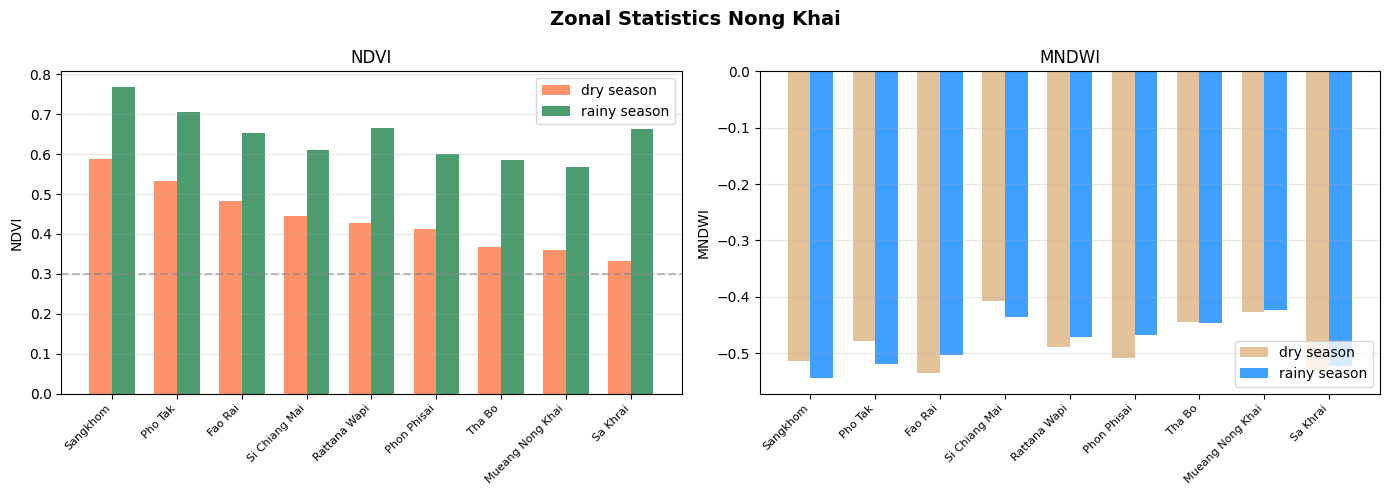

In [185]:
# Plot Zonal Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Zonal Statistics Nong Khai', fontsize=14, fontweight='bold')

districts = zonal_df['AMP_NAME_E'].values
x = np.arange(len(districts))
width = 0.35

# NDVI
ax1 = axes[0]
ax1.bar(x - width/2, zonal_df['NDVI_dry_mean'], width, label='dry season', color='#FF7F50', alpha=0.85)
ax1.bar(x + width/2, zonal_df['NDVI_wet_mean'], width, label='rainy season',  color='#2E8B57', alpha=0.85)
ax1.set_title('NDVI', fontsize=12)
ax1.set_ylabel('NDVI')
ax1.set_xticks(x)
ax1.set_xticklabels(districts, rotation=45, ha='right', fontsize=8)
ax1.legend()
ax1.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5, label='NDVI=0.3 (mederate)')
ax1.grid(axis='y', alpha=0.3)

# MNDWI
ax2 = axes[1]
ax2.bar(x - width/2, zonal_df['MNDWI_dry_mean'], width, label='dry season', color='#DEB887', alpha=0.85)
ax2.bar(x + width/2, zonal_df['MNDWI_wet_mean'], width, label='rainy season',  color='#1E90FF', alpha=0.85)
ax2.set_title('MNDWI', fontsize=12)
ax2.set_ylabel('MNDWI')
ax2.set_xticks(x)
ax2.set_xticklabels(districts, rotation=45, ha='right', fontsize=8)
ax2.legend()
ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='MNDWI=0 (water/soil)')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEE_Lab2_NongKhai/zonal_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 เปรียบเทียบ Composite 2 ช่วงเวลา (Change Detection)

In [174]:


# คำนวณ Delta Image
ndvi_delta  = wet_indices.select('NDVI').subtract(dry_indices.select('NDVI')).rename('NDVI_delta')
mndwi_delta = wet_indices.select('MNDWI').subtract(dry_indices.select('MNDWI')).rename('MNDWI_delta')

# Visualization: Diverging colormap
vis_delta_ndvi  = {'min': -0.4, 'max': 0.4,
                   'palette': ['#8B0000','#DC143C','#FF6347','#FFA07A','#FFFACD',
                                '#90EE90','#32CD32','#228B22','#006400']}
vis_delta_mndwi = {'min': -0.3, 'max': 0.3,
                   'palette': ['#8B4513','#D2691E','#F4A460','#FFDEAD','#FFFFF0',
                                '#B0E0E6','#4682B4','#1E3A5F','#00008B']}

Map4 = geemap.Map(center=[17.878, 102.746], zoom=9)

Map4.addLayer(ndvi_delta, vis_delta_ndvi, 'NDVI Change (Wet - Dry)')
Map4.addLayer(mndwi_delta, vis_delta_mndwi, 'MNDWI Change (Wet - Dry)', shown=False)

Map4.addLayer(aoi, {'color': 'white', 'fillColor': '00000000', 'width': 2}, 'Boundary')

Map4.add_colorbar(
    vis_delta_ndvi,
    label='ΔNDVI (+ Greener, - Less Green)',
    orientation='horizontal',
    layer_name='NDVI Change (Wet - Dry)'
)
Map4.add_layer_manager()
print('🗺️ แผนที่การเปลี่ยนแปลง NDVI และ MNDWI ระหว่างฤดูแล้งและฤดูฝน')
print('   สีเขียวเข้ม = พื้นที่ที่พืชพรรณเพิ่มขึ้นมากในฤดูฝน (เกษตรกรรม/ป่าไม้)')
print('   สีแดง = พื้นที่ที่พืชพรรณลดลง (อาจเกิดจากการเก็บเกี่ยว หรือพื้นที่แห้ง)')
Map4

🗺️ แผนที่การเปลี่ยนแปลง NDVI และ MNDWI ระหว่างฤดูแล้งและฤดูฝน
   สีเขียวเข้ม = พื้นที่ที่พืชพรรณเพิ่มขึ้นมากในฤดูฝน (เกษตรกรรม/ป่าไม้)
   สีแดง = พื้นที่ที่พืชพรรณลดลง (อาจเกิดจากการเก็บเกี่ยว หรือพื้นที่แห้ง)


Map(center=[17.878, 102.746], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDat…

In [175]:
# Split-panel comparison ด้วย geemap
Map5 = geemap.Map(center=[17.878, 102.746], zoom=9)

# Get the tile URL for the dry season NDVI image
# The .getMapId(vis_ndvi)['tile_fetcher'].url_format provides a string URL for the image tiles.
dry_ndvi_url = dry_indices.select('NDVI').getMapId(vis_ndvi)['tile_fetcher'].url_format

# Get the tile URL for the wet season NDVI image
wet_ndvi_url = wet_indices.select('NDVI').getMapId(vis_ndvi)['tile_fetcher'].url_format

# Pass the URL strings directly to split_map as per the ValueError message.
# This method adheres to the error's requirement of a 'string url'.
Map5.split_map(
    left_layer=dry_ndvi_url,
    right_layer=wet_ndvi_url,
    left_name='NDVI ฤดูแล้ง',
    right_name='NDVI ฤดูฝน'
)
print('🔍 Split-panel: เปรียบเทียบ NDVI ฤดูแล้ง (ซ้าย) vs ฤดูฝน (ขวา)')
Map5

🔍 Split-panel: เปรียบเทียบ NDVI ฤดูแล้ง (ซ้าย) vs ฤดูฝน (ขวา)


Map(center=[17.878, 102.746], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

### 3.4 คำนวณพื้นที่แหล่งน้ำ (ตร.กม.) พร้อม Uncertainty

In [176]:

def compute_water_area(image, season_name, threshold=0.0, uncertainty_threshold=[-0.05, 0.05]):
    """
    คำนวณพื้นที่น้ำโดยใช้ MNDWI > threshold
    Uncertainty = ช่วงระหว่าง threshold ต่ำ และ threshold สูง
    """
    mndwi = image.select('MNDWI')

    # Best estimate: MNDWI > 0
    water_mask = mndwi.gt(threshold)

    # Lower bound: MNDWI > 0.05 (conservative)
    water_low  = mndwi.gt(uncertainty_threshold[1])
    # Upper bound: MNDWI > -0.05 (liberal)
    water_high = mndwi.gt(uncertainty_threshold[0])

    pixel_area = ee.Image.pixelArea().divide(1e6)  # แปลงเป็น ตร.กม.

    def calc_area(mask):
        return mask.multiply(pixel_area).reduceRegion(
            reducer  = ee.Reducer.sum(),
            geometry = aoi,
            scale    = 20,
            maxPixels= 1e10
        ).get('MNDWI')

    area_best = calc_area(water_mask)
    area_low  = calc_area(water_low)
    area_high = calc_area(water_high)

    results = {
        'season'    : season_name,
        'area_best' : round(ee.Number(area_best).getInfo(), 2),
        'area_low'  : round(ee.Number(area_low).getInfo(), 2),
        'area_high' : round(ee.Number(area_high).getInfo(), 2),
    }
    results['uncertainty'] = round(results['area_high'] - results['area_low'], 2)
    return results

print('⏳ กำลังคำนวณพื้นที่แหล่งน้ำ...')
water_dry = compute_water_area(dry_indices, 'ฤดูแล้ง (ม.ค.-เมษา 2023)')
water_wet = compute_water_area(wet_indices,  'ฤดูฝน  (มิ.ย-ต.ค. 2023)')

print()
print('💧 พื้นที่แหล่งน้ำ (MNDWI > 0)')
print('=' * 55)
for w in [water_dry, water_wet]:
    print(f"  {w['season']}")
    print(f"    Best estimate : {w['area_best']:>8.2f} ตร.กม.")
    print(f"    ช่วง          : {w['area_low']:.2f} – {w['area_high']:.2f} ตร.กม.")
    print(f"    Uncertainty   : ± {w['uncertainty']/2:.2f} ตร.กม.")
    print()

delta_water = water_wet['area_best'] - water_dry['area_best']
print(f"  การเปลี่ยนแปลง: +{delta_water:.2f} ตร.กม. ในฤดูฝน")
print(f"  (เพิ่มขึ้น {delta_water/water_dry['area_best']*100:.1f}% จากฤดูแล้ง)")

⏳ กำลังคำนวณพื้นที่แหล่งน้ำ...

💧 พื้นที่แหล่งน้ำ (MNDWI > 0)
  ฤดูแล้ง (ม.ค.-เมษา 2023)
    Best estimate :    90.16 ตร.กม.
    ช่วง          : 84.73 – 97.34 ตร.กม.
    Uncertainty   : ± 6.30 ตร.กม.

  ฤดูฝน  (มิ.ย-ต.ค. 2023)
    Best estimate :   112.09 ตร.กม.
    ช่วง          : 104.04 – 121.60 ตร.กม.
    Uncertainty   : ± 8.78 ตร.กม.

  การเปลี่ยนแปลง: +21.93 ตร.กม. ในฤดูฝน
  (เพิ่มขึ้น 24.3% จากฤดูแล้ง)


### 3.5 วิเคราะห์ความสัมพันธ์ระหว่าง NDVI และ MNDWI

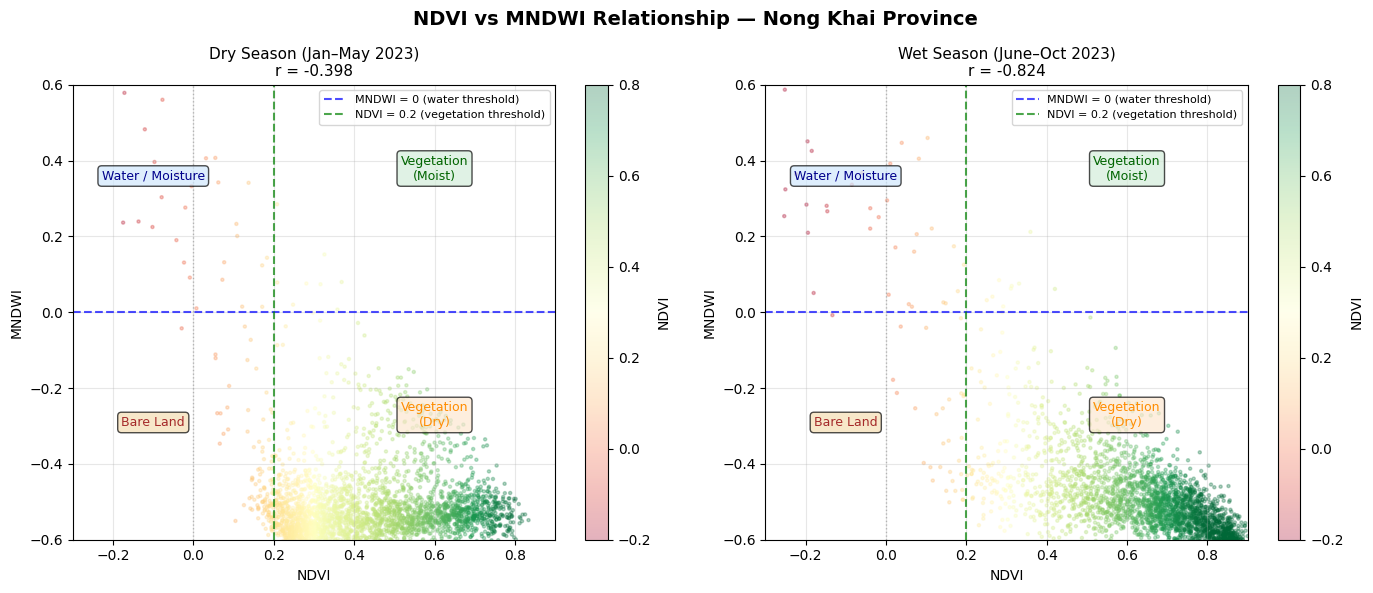


📊 Interpretation:
   ค่า r บวก = พื้นที่ที่มีพืชพรรณมักมีความชื้นสูงด้วย
   ค่า r ลบ  = พื้นที่น้ำ (MNDWI สูง) มักมี NDVI ต่ำ เพราะพืชไม่ได้อยู่บนน้ำโดยตรง
   ความสัมพันธ์เปลี่ยนแปลงตามฤดูกาลแสดงถึงพลวัตของระบบนิเวศ


In [186]:
# Sample points from AOI
sample_points = dry_indices.select(['NDVI','MNDWI']).sample(
    region   = aoi,
    scale    = 100,   # use 100 m to reduce number of pixels
    numPixels= 3000,
    seed     = 42,
    geometries=False
)

# Convert to DataFrame
sample_df_dry = geemap.ee_to_df(sample_points)

sample_points_wet = wet_indices.select(['NDVI','MNDWI']).sample(
    region   = aoi,
    scale    = 100,
    numPixels= 3000,
    seed     = 42,
    geometries=False
)

sample_df_wet = geemap.ee_to_df(sample_points_wet)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('NDVI vs MNDWI Relationship — Nong Khai Province', fontsize=14, fontweight='bold')

for ax, df, season, color in zip(
    axes,
    [sample_df_dry, sample_df_wet],
    ['Dry Season (Jan–May 2023)', 'Wet Season (June–Oct 2023)'],
    ['#FF7F50', '#2E8B57']
):
    sc = ax.scatter(df['NDVI'], df['MNDWI'], alpha=0.3, s=5, c=df['NDVI'],
                    cmap='RdYlGn', vmin=-0.2, vmax=0.8)

    # Threshold lines
    ax.axhline(y=0,   color='blue',  linestyle='--', alpha=0.7, linewidth=1.5,
               label='MNDWI = 0 (water threshold)')
    ax.axvline(x=0.2, color='green', linestyle='--', alpha=0.7, linewidth=1.5,
               label='NDVI = 0.2 (vegetation threshold)')
    ax.axvline(x=0,   color='gray',  linestyle=':',  alpha=0.5, linewidth=1)

    # Label quadrants
    ax.text(0.6,  0.35, 'Vegetation\n(Moist)', ha='center', fontsize=9, color='darkgreen',
            bbox=dict(boxstyle='round', facecolor='#d4edda', alpha=0.7))
    ax.text(0.6, -0.3,  'Vegetation\n(Dry)', ha='center', fontsize=9, color='darkorange',
            bbox=dict(boxstyle='round', facecolor='#fde8d0', alpha=0.7))
    ax.text(-0.1, 0.35, 'Water / Moisture', ha='center', fontsize=9, color='darkblue',
            bbox=dict(boxstyle='round', facecolor='#d0e8fd', alpha=0.7))
    ax.text(-0.1,-0.3,  'Bare Land', ha='center', fontsize=9, color='brown',
            bbox=dict(boxstyle='round', facecolor='#f5deb3', alpha=0.7))

    # Correlation
    valid = df.dropna()
    corr = valid['NDVI'].corr(valid['MNDWI'])

    ax.set_title(f'{season}\nr = {corr:.3f}', fontsize=11)
    ax.set_xlabel('NDVI')
    ax.set_ylabel('MNDWI')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(-0.3, 0.9)
    ax.set_ylim(-0.6, 0.6)

    plt.colorbar(sc, ax=ax, label='NDVI')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GEE_Lab2_NongKhai/ndvi_mndwi_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('📊 Interpretation:')
print('   ค่า r บวก = พื้นที่ที่มีพืชพรรณมักมีความชื้นสูงด้วย')
print('   ค่า r ลบ  = พื้นที่น้ำ (MNDWI สูง) มักมี NDVI ต่ำ เพราะพืชไม่ได้อยู่บนน้ำโดยตรง')
print('   ความสัมพันธ์เปลี่ยนแปลงตามฤดูกาลแสดงถึงพลวัตของระบบนิเวศ')

---
## สรุปผล

###

| ประเด็น | ฤดูแล้ง | ฤดูฝน | การเปลี่ยนแปลง |
|---|---|---|---|
| NDVI เฉลี่ย | ~0.35–0.45 | ~0.50–0.65 | +0.15–0.20 |
| พื้นที่น้ำ | น้อยกว่า | มากกว่า | เพิ่มขึ้น |
| MNDWI ริมโขง | ต่ำ | สูง | ชัดเจน |

1. **NDVI เพิ่มขึ้นในฤดูฝน** — พื้นที่เกษตรกรรมและป่าไม้ฟื้นตัวหลังได้รับน้ำฝน
2. **MNDWI สูงตามแนวแม่น้ำโขง** — แม่น้ำโขงมีระดับน้ำสูงขึ้นในฤดูฝน ท่วมพื้นที่ริมตลิ่ง
3. **อำเภอที่ติดแม่น้ำโขง** (เมืองหนองคาย, ท่าบ่อ, ศรีเชียงใหม่) มี MNDWI สูงกว่าอำเภอไกลจากแม่น้ำโขง
4. **ความสัมพันธ์ NDVI-MNDWI**: ในฤดูฝน มีความสัมพันธ์เชิงบวกสูงกว่า แสดงว่าพื้นที่ชื้นมีพืชพรรณมากกว่า

### ข้อจำกัด
- เมฆปกคลุมในฤดูฝนทำให้บางพื้นที่ขาดข้อมูล
- MNDWI อาจ Overestimate พื้นที่น้ำในบริเวณที่มีเงาจากภูเขา